In [1]:
import pandas as pd
import zipfile
from scipy.sparse import coo_matrix
import numpy as np

In [3]:
def calculte_m(area_distr, eff_population, graph, mobility_rate):
    c = 2e-4
    f =  2 - np.exp(-c*(eff_population / area_distr))

    f_neff = f / eff_population

    #m1 and m2 are 0 if p=1

    m1 = ((1-mobility_rate) **2) * f_neff
    m1 = np.diag(m1) #kronegers thing makes it a diagonal


    #r_ij multipleid by f/neff_j
    term_1 = graph.multiply(f_neff[np.newaxis, :])
    #r_ji (same as transpose term 1)
    term_2 = graph.T.multiply(f_neff[:, np.newaxis])
    m2 = mobility_rate * (1-mobility_rate) * (term_1 + term_2).toarray()

    #ril * nf_neff is same as term 1, then matrix mult with transpose to get m3
    m3= (mobility_rate**2) * (term_1 @ graph.T).toarray()

    return m1 + m2 + m3

In [4]:
from scipy.linalg import eig


def generate_data(input_graph, input_area_distr, recovery_rate, population, mobility_rate=1, ):
    graph = input_graph
    #visualise_graph(graph)

    #calculat eff population formula 6 from papaer

    eff_population = (1 - mobility_rate) * population + mobility_rate * np.array(graph.T.dot(population)).flatten()
    eff_population[eff_population == 0] = 1

    #devide area acording to log-linear dist

    area_distr = input_area_distr
    area_distr[area_distr == 0] = 1

    matrix_m = calculte_m(area_distr, eff_population, graph, 1)
    matrix_m = matrix_m * population[np.newaxis, :]

    # --- diagnostics ---
    # print("area_distr NaNs:", np.isnan(area_distr).sum(), "zeros:", (area_distr == 0).sum())
    # print("eff_population NaNs:", np.isnan(eff_population).sum())
    # print("population NaNs:", np.isnan(population).sum())
    # print("matrix_m NaNs:", np.isnan(matrix_m).sum(), "Infs:", np.isinf(matrix_m).sum())

    eigenvalues, _ = eig(matrix_m)
    spectral_radius = np.max(np.abs(eigenvalues))

    # -------------------

    # matrix_m_2 = calculte_m(area_distr, eff_population, graph, 0)
    #
    # eigenvalues_2, _ = eigs(matrix_m_2, k=1, which='LM')
    # spectral_radius_2 = np.abs(eigenvalues_2[0])

    # print(spectral_radius)
    # print(spectral_radius_2)

    print(recovery_rate / spectral_radius)
    return recovery_rate / spectral_radius






In [5]:



def process_data(df_test, counties, id):
    #add land arae data
    df_test['geoid_o'] = df_test['geoid_o'].astype(str)
    df_test['geoid_d'] = df_test['geoid_d'].astype(str)
    counties['GEOID'] = counties['GEOID'].astype(str)

    df_test['geoid_o'] = df_test['geoid_o'].apply(lambda x: x.zfill(5) )
    df_test['geoid_d'] = df_test['geoid_d'].apply(lambda x: x.zfill(5) )
    counties['GEOID'] = counties['GEOID'].apply(lambda x: x.zfill(5) )


    df_merged = df_test.merge(counties[['GEOID', 'area_km2']], left_on='geoid_o', right_on='GEOID', how='left')
    df_merged= df_merged.drop(columns=['lng_o', 'lng_d', 'lat_o', 'lat_d', 'date_range', 'visitor_flows', 'GEOID'])

    #filter georgia
    # df_merged = df_merged[df_merged['geoid_o'].str.startswith('13')] # only starting from georgia
    #california
    # df_merged = df_merged[df_merged['geoid_o'].str.startswith('06')]
    df_merged = df_merged[df_merged['geoid_o'].str.startswith('48')]

    df_merged = df_merged [df_merged['geoid_d'].isin(df_merged['geoid_o'].unique())]

    #label the nodes
    all_nodes = pd.concat([df_merged['geoid_o'], df_merged['geoid_d']]).unique()
    node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}
    number_nodes = len(all_nodes)


    ordered_geoids = [geoid for geoid, idx in sorted(node_to_idx.items(), key=lambda x: x[1])]

    #popoulation
    population = (df_merged.groupby('geoid_o')['pop_flows'].sum() / 7).reset_index()
    population= population.rename(columns= {'pop_flows' : 'total_populaiton'})

    #flows
    df_merged_pop = df_merged.merge(population, on='geoid_o', how='left')
    df_merged_pop['pop_flows'] = df_merged_pop['pop_flows'] / 7

    # 3. Area — one area per geoid_o, reindex to same order
    area_distr = (df_merged_pop.drop_duplicates('geoid_o')
                    .set_index('geoid_o')['area_km2']
                    .reindex(ordered_geoids)
                    .fillna(0)
                    .values) *  0.386

    #make into graph
    rows = df_merged_pop['geoid_o'].map(node_to_idx).values
    cols = df_merged_pop['geoid_d'].map(node_to_idx).values
    weights = (df_merged_pop['pop_flows'] / df_merged_pop['total_populaiton']).values
    graph = coo_matrix((weights, (rows, cols)), shape=(number_nodes, number_nodes))



    population = (df_merged_pop.drop_duplicates('geoid_o')
                  .set_index('geoid_o')['total_populaiton']
                  .reindex(ordered_geoids)
                  .fillna(0)
                  .astype(float)
                  .values)
    threshold = generate_data(graph, area_distr, 1, population, 1)


    position_array = np.zeros((number_nodes, 2))
    edge_index = torch.tensor(np.vstack((graph.row, graph.col)), dtype=torch.long)

    # 2. edge_attr: Shape [num_edges, 1], type float32
    edge_attr = torch.tensor(graph.data, dtype=torch.float32).view(-1, 1)

    # 3. x (Node features): Combine population and position, Shape [num_nodes, 3], type float32
    node_features = np.column_stack((population, area_distr, position_array))
    x = torch.tensor(node_features, dtype=torch.float32)

    # 4. y (Target label): Shape [1], type float32
    y = torch.tensor([threshold], dtype=torch.float32)

    # --- Construct PyG Data Object ---
    data_obj = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
    data_obj.graph_id = id

    return data_obj





In [6]:

import torch
from torch_geometric.data import Data
import numpy as np
import os






In [7]:
import geopandas as gpd

# Census TIGER county boundaries, directly from the US Census Bureau
url = "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_county_500k.zip"
counties = gpd.read_file(url)

# Project to equal-area for accurate km² calculation
counties = counties.to_crs(epsg=6933)
counties['area_km2'] = counties.geometry.area / 1e6

# Keep just what you need
area = counties[['GEOID', 'area_km2']]

In [10]:
zip_file_path = "datasets/real data/county2county2021.zip"
pyg_graphs = []


with zipfile.ZipFile(zip_file_path, 'r') as z:
    # Loop through every file inside the zip
    i=0
    for filename in z.namelist():

        if not filename.endswith('.csv') or '__MACOSX' in filename or filename.split('/')[-1].startswith('._'):
            continue

        # Open and process the CSV
        with z.open(filename) as f:
            # Load into memory temporarily
            df = pd.read_csv(f)

            clean_name = filename.replace(".csv", "")

            # 2. Split the string by underscores
            parts = clean_name.split("_")
            print(parts)
            # Outputs: ['weekly', 'county2county', '2019', '02', '11']

            date_tracker = "-".join(parts[-3:])


            graph = process_data(df_test = df, counties = counties, id = date_tracker)
            pyg_graphs.append(graph)

            print(f"proccesed {i} graph")
        i +=1


save_path = '/Users/emmapinckers/PycharmProjects/thesis/data generation/datasets/version1/texas_all_2021.pt'

torch.save(pyg_graphs, save_path)

            # Memory management: processed_df will be overwritten
            # on the next iteration, freeing up RAM.

['county2county2021/weekly', 'county2county', '2021', '09', '20']
0.7466500799338753
proccesed 0 graph
['county2county2021/weekly', 'county2county', '2021', '07', '19']
0.769476819756263
proccesed 1 graph
['county2county2021/weekly', 'county2county', '2021', '02', '01']
0.7705851932432459
proccesed 2 graph
['county2county2021/weekly', 'county2county', '2021', '02', '15']
0.7916140392785995
proccesed 3 graph
['county2county2021/weekly', 'county2county', '2021', '12', '06']
0.7714677352497304
proccesed 4 graph
['county2county2021/weekly', 'county2county', '2021', '07', '26']
0.7670534545739569
proccesed 5 graph
['county2county2021/weekly', 'county2county', '2021', '12', '13']
0.7652954839159114
proccesed 6 graph
['county2county2021/weekly', 'county2county', '2021', '09', '27']
0.75002087106121
proccesed 7 graph
['county2county2021/weekly', 'county2county', '2021', '05', '24']
0.7470908181457505
proccesed 8 graph
['county2county2021/weekly', 'county2county', '2021', '10', '11']
0.74349756

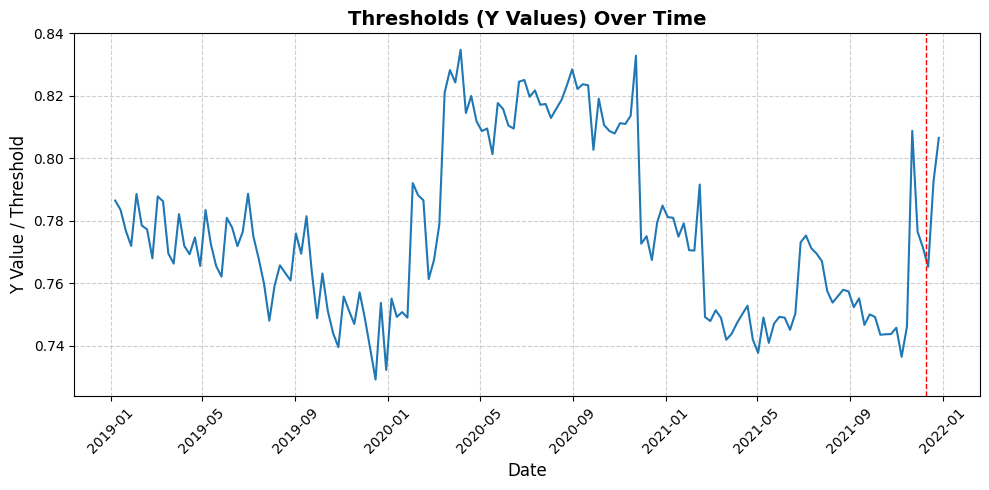

In [16]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load your saved list of PyG graphs
g2019 = torch.load("/Users/emmapinckers/PycharmProjects/thesis/data generation/datasets/version1/texas_all_2019.pt", weights_only= False)

g2020 = torch.load("/Users/emmapinckers/PycharmProjects/thesis/data generation/datasets/version1/texas_all_covid.pt", weights_only= False)

g2021 = torch.load("/Users/emmapinckers/PycharmProjects/thesis/data generation/datasets/version1/texas_all_2021.pt", weights_only= False)

# 2. Extract the tracker dates and target Y values into a raw list
all_years = [g2019, g2020, g2021]

raw_data = []
for year in all_years:
    for data_obj in year:
        # item() converts a single-value torch tensor into a standard Python number
        y_value = data_obj.y.item() if hasattr(data_obj.y, "item") else data_obj.y

        raw_data.append({
            "date": data_obj.graph_id,
            "y_value": y_value
        })

# 3. Create a pandas DataFrame for easy sorting and formatting
df_plot = pd.DataFrame(raw_data)

# 4. CRITICAL: Convert strings to actual datetime objects so sorting works perfectly
df_plot['date'] = pd.to_datetime(df_plot['date'])

# 5. Sort chronologically so your line plot doesn't zig-zag backward and forward
df_plot = df_plot.sort_values('date').reset_index(drop=True)


# 6. Generate the Plot
plt.figure(figsize=(10, 5))
plt.plot(df_plot['date'], df_plot['y_value'], linestyle='-', color='tab:blue')

# # --- ADD YOUR VERTICAL LINE HERE ---
# target_date = pd.to_datetime('2020-03-19') # Replace with your specific date
# plt.axvline(x=target_date, color='red', linestyle='--', linewidth=2, label='Policy Change')
#
# target_date = pd.to_datetime('2020-06-15') # Replace with your specific date
# plt.axvline(x=target_date, color='blue', linestyle='--', linewidth=2, label='Policy Change End')
#
target_date = pd.to_datetime('2021-12-10') # Replace with your specific date
plt.axvline(x=target_date, color='red', linestyle='--', linewidth=1, label='Policy Change End')

# Clean up formatting
# plt.ylim(0.69, 0.88)
plt.title("Thresholds (Y Values) Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Y Value / Threshold", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.xticks(rotation=45)
plt.tight_layout()

# Add a legend so the vertical line's label ("Policy Change") shows up
# plt.legend()
plt.show()